#### Sampling with DBM (W1)
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import importlib, itertools, time, pickle
import sampler, densities, fmm
from IPython.display import clear_output

# Avoid messy output for Euler method.
import warnings
# warnings.filterwarnings('ignore', category = RuntimeWarning)

importlib.reload(sampler); importlib.reload(densities); importlib.reload(fmm);
sampler.hello()

Hello from the sampler file!


In [2]:
# NOTE Tweak as wanted.
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["cmr10"], 
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    
    "figure.figsize": (6.5, 3),
    "figure.dpi": 120,
    "figure.constrained_layout.use": True,
    
    "lines.linewidth": 1.25,
    "lines.markersize": 2,
    "axes.linewidth": 0.8,
    "axes.formatter.use_mathtext": True
})

---
---
---

1. Convergence of $N$-densities to the true equilibrium density $\rho(x)$.
See Li and Menon.

Compare quad-quartic ($x^2/2 + x^4/4$) and pure quartic ($x^4/4$) for $N = 6$ and $N = 30$ respectively. Files: `densities.py`.

In [ ]:
# CALCULATE limiting and N-distributions.
importlib.reload(densities);
param_choices = [(6, "quad-quartic"), (30, "quad-quartic"), (6, "quartic"), (30, "quartic")]
# param_choices = [(6, "quadratic"), (30, "quadratic")]
grid = np.linspace(-2.5, 2.5, 500) 
K_Ns = []
rhos = []

def get_potential(type):
    if (type == "quad-quartic"):
        return lambda x: x**2/2 + x**4/4
    elif (type == "quartic"):
        return lambda x: x**4/4
    elif (type == "quadratic"):
        return lambda x: x**2/2
    else:
        raise ValueError(f"Potential {type} not found.")
    
for k, choices in enumerate(param_choices):
    N, pot_type = choices
    potential = get_potential(pot_type)

    # Same process as in paper, uses GS construction.
    pis, c_sqrs = densities.orthogonal_polys(N, potential, grid)
    K_N = densities.construct_kernel(N, potential, grid, pis, c_sqrs)

    q = 1 if ("quad" in pot_type) else 0
    g = 0 if (pot_type == "quadratic") else 1
    rho = densities.theoretical_density(grid, q = q, g = g)

    K_Ns.append(np.diag(K_N) / N) # Moved from the plotting part.
    rhos.append(rho)

In [ ]:
# PLOT limiting against N-distributions.
plot_names = ["A", "B", "C", "D"]
# plot_names = ["semicircle-A", "semicircle-B"]
for (K_N, rho, name) in zip(K_Ns, rhos, plot_names):
    # Clip grid to [-1.5, 1.5] to matchb resolution on paper.
    clip_range = 1.5 # Change if using semicircle.
    clipped_range = np.abs(grid) <= clip_range
    grid_clipped = grid[clipped_range]
    K_N_clipped = K_N[clipped_range]
    rho_clipped = rho[clipped_range]

    fig, ax = plt.subplots()
    ax.plot(grid_clipped, K_N_clipped, "b-", linewidth = 1.5, label = rf"Density $K_N(x)$.")
    ax.plot(grid_clipped, rho_clipped, "r--", linewidth = 1.5, label = rf"Limiting density $\rho(x)$.")

    # ax.set_title(rf"Convergence of $K_N(x)$ to $\rho(x)$: $N = $ {N}.")
    ax.set_xlabel('$x$');
    ax.set_ylabel('Density')
    ax.grid(True, alpha = 0.3)
    ax.set_xlim(-1*clip_range - 0.25, clip_range + 0.25)
    # ax.legend(loc = "best")

    plt.tight_layout()
    plt.show()
    # plt.savefig(f"figures/density-plot-{name}.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")
    plt.close()

---

EXAMPLE PLOTS: Long-run sampling for large $N$ ($N = 500$ and $N = 1000$).

In [75]:
saved_data = np.load("data/long-simulations.npz")
results = saved_data["n500t10"][0]; results2 = saved_data["n1000t5"][0]

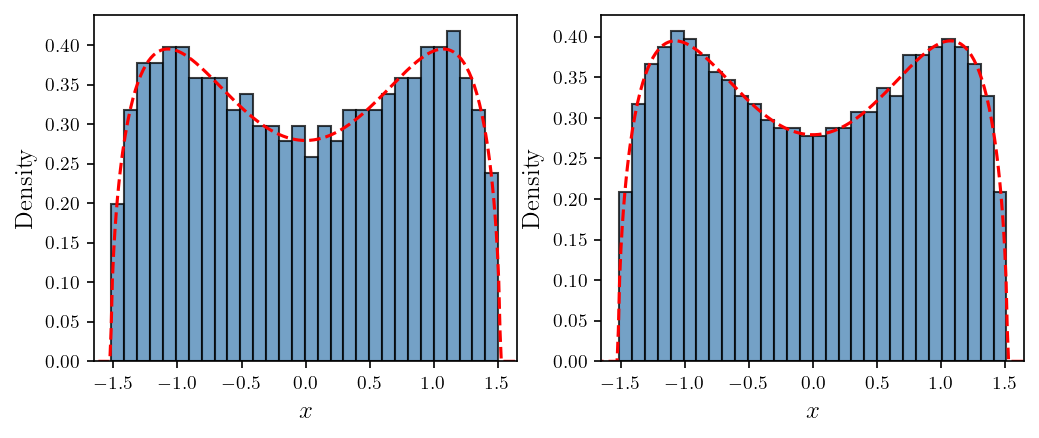

In [76]:
s_vals = np.linspace(-2.5, 2.5, 500)
density = densities.theoretical_density(s_vals, q = 0, g = 1)
fig1, axes = plt.subplots(1, 2, figsize = (8, 3))
ax1, ax2 = axes

ax1.hist(results, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax1.plot(s_vals, density, 'r--')

# fig2, ax2 = plt.subplots()
ax2.hist(results2, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax2.plot(s_vals, density, "r--")

for ax in [ax1, ax2]:
    ax.set_xlim(-1.65, 1.65)
    ax.set_ylabel("Density")
    ax.set_xlabel(r"$x$")

# fig1.savefig("figures/implicit-long-run-hists-N500.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")
# fig2.savefig("figures/implicit-long-run-hists-N1000.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")

plt.show()

---
---
---

08/06: investigation into the bias and Monte Carlo error of each method (mainly focusing on tamed and implicit schemes).

10/06: re-run now with Wasserstein distance (pass `distance_types = ["ks", "wasserstein"]` into the sampler and rearrange dictionary as appropriate.)
Run now for $T = 8.0$. For bias use $M = 50$ for $N = 20, 50$. For MC error use $N = 20, 50$ and just look at the implicit method, use $dt = 1/N$  to minimise bias. Plot traces of errors but also plot average of long-time (e.g. avg of $T = 5.0, 5.5, 6.0, ...$) errors with $\Delta t$ and $M$ depending on experiment.

11/06: long run finished, load and see. (Note henceforth use pickle instead of `.npz`.)

In [9]:
# Reload saved .npz data and recompile into dictionary.
# NOTE use pickle from now on.
data_loaded = np.load("data/LONG-wass-bias-investigation-2.npz")
N_ranges = data_loaded["N"]; k_range = data_loaded["k_range"]; methods = data_loaded["methods"];
M = data_loaded["M"]; T = data_loaded["T"]

bias_results = {}
final_distances = {(N, method): {"k": [], "ks_final": [], "wass_final": []} for N, method in itertools.product(N_ranges, methods)}

for N, k, method in itertools.product(N_ranges, k_range, methods):
            prefix = f"N{N}-k{k}-{method}"

            if f"{prefix}_ks_times" in data_loaded:
                ks_distances = data_loaded[f"{prefix}_ks_distances"]
                wass_distances = data_loaded[f"{prefix}_wass_distances"]
                
                final_distances[(N, method)]["k"].append(k)
                final_distances[(N, method)]["ks_final"].append(ks_distances[-1])
                final_distances[(N, method)]["wass_final"].append(wass_distances[-1])

                bias_results[(N, k, method)] = {
                    "ks_times": data_loaded[f"{prefix}_ks_times"],
                    "ks_distances": ks_distances,
                    "wass_times": data_loaded[f"{prefix}_wass_times"],
                    "wass_distances": wass_distances,
                    "ks_final": ks_distances[-1],
                    "wass_final": wass_distances[-1], 
                    "particles": data_loaded[f"{prefix}_particles"]
                }
            else:
                raise ValueError(f"Did not find key {prefix}_ks_times.")
            
N_ranges, k_range, methods, M, T

(array([20, 50], dtype=int32),
 array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13], dtype=int32),
 array(['euler', 'tamed', 'implicit'], dtype='<U8'),
 array(50, dtype=int32),
 array(8.))

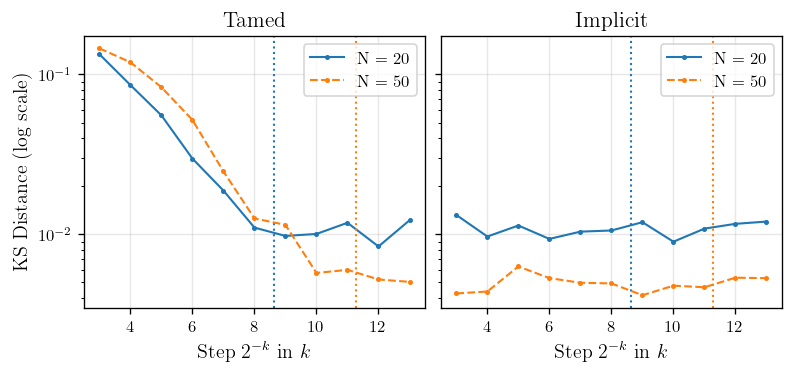

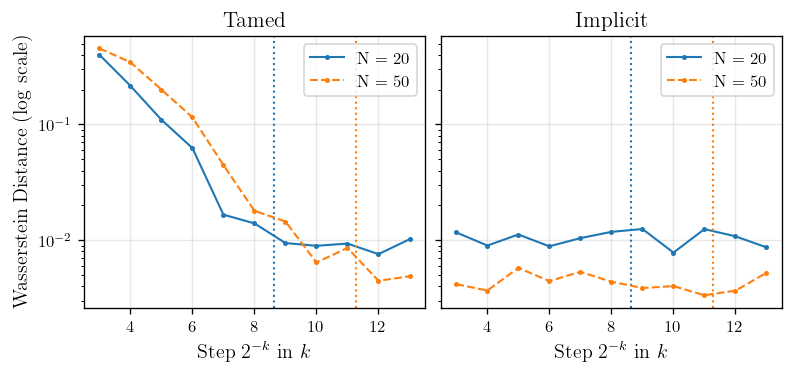

In [ ]:
# Plotter for bias-step size.
# Dictionary key (N, k, method), has times, distances, and final.
# Create new arrays for final time for easy plotting against k. (T=8 is final).
final_ks = {}
final_wass = {}

for N, method in itertools.product(N_ranges, methods):
    final_ks[(N, method)] = [bias_results[(N, k, method)]["ks_final"] for k in k_range]
    final_wass[(N, method)] = [bias_results[(N, k, method)]["wass_final"] for k in k_range]

methods = ["tamed", "implicit"] # remove Euler plot for now.

# First figure for KS, second for Wasserstein.
fig, axes = plt.subplots(1, len(methods), sharey = True)
axes = axes.flatten()

linestyles = ["-", "--"]; colours = plt.cm.tab10.colors
for ax, method in zip(axes, methods):
    for j, N in enumerate(N_ranges):
        ax.plot(k_range, final_ks[(N, method)], label = f"N = {N}", 
                linestyle = linestyles[j], color = colours[j], marker = 'o')

        k_star = 2*np.log2(N)
        ax.axvline(k_star, color = colours[j], linestyle = ":")

    ax.grid(True, alpha = 0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Step $2^{-k}$ in $k$")
    ax.set_title(method.capitalize())
    ax.legend(loc = "upper right")

axes[0].set_ylabel("KS Distance (log scale)")

plt.show()

# Second figure for Wasserstein (no changes)
fig2, axes = plt.subplots(1, len(methods), sharey = True)
axes = axes.flatten()

linestyles = ["-", "--"]; colours = plt.cm.tab10.colors
for ax, method in zip(axes, methods):
    for j, N in enumerate(N_ranges):
        ax.plot(k_range, final_wass[(N, method)], label = f"N = {N}", 
                linestyle = linestyles[j], color = colours[j], marker = 'o')

        k_star = 2*np.log2(N)
        ax.axvline(k_star, color = colours[j], linestyle = ":")

    ax.grid(True, alpha = 0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Step $2^{-k}$ in $k$")
    ax.set_title(method.capitalize())
    ax.legend(loc = "upper right")

axes[0].set_ylabel("Wasserstein Distance (log scale)")

# fig.savefig("figures/bias-two-methods-ks.pdf", format = "pdf")
# fig2.savefig("figures/bias-two-methods-wass.pdf", format = "pdf")

plt.show()

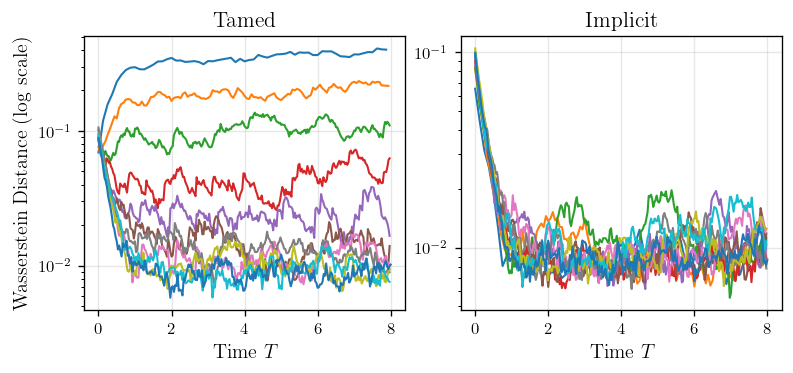

In [ ]:
# Plotter for bias-step size, all trajecs.
# Dictionary key (N, k, method), has times, distances, and final.
fig, axes = plt.subplots(1, 2)
colours = plt.cm.tab10.colors

for ax, method in zip(axes, ["tamed", "implicit"]):
    for k in k_range:
        data = bias_results[(20, k, method)]
        ax.plot(data["ks_times"], data["wass_distances"], label = k)

    ax.set_yscale("log")
    ax.set_xlabel("Time $T$")
    ax.set_title(method.capitalize())
    ax.grid(True, alpha = 0.3)

axes[0].set_ylabel("Wasserstein Distance (log scale)")
# plt.savefig("figures/bias-all-trajecs-two-methods.pdf", format = "pdf")
plt.show()

---
---
---
---
---

An old Monte Carlo error experiment.

In [3]:
loaded_data = np.load("data/mc_error-investigation-2.npz")
mc_error_results = {}

for key in loaded_data.files:
    if key.endswith("_times"):
        prefix = key.replace("_times", "")
        parts = prefix.split("-")
        
        M = int(parts[0][1:])
        dt_choice = parts[1][2:]
        method = parts[2]
        
        mc_error_results[(M, dt_choice, method)] = {
            "times": loaded_data[f"{prefix}_times"],
            "distances": loaded_data[f"{prefix}_distances"],
            "particles": loaded_data[f"{prefix}_particles"]
        }

N = loaded_data["N"][0]
T = loaded_data["T"][0]

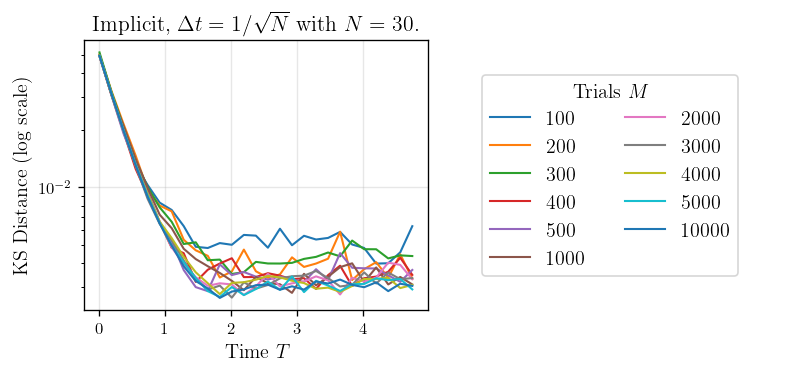

In [7]:
fig, axes = plt.subplots(1, 2)
ax, ax2 = axes

# NOTE should clean this up so can just reload data.
fixed_method = "implicit"
M_range = [100, 200, 300, 400, 500, 1000, 2000, 3000, 4000, 5000, 10000]

for j, M in enumerate(M_range):
    key = (M, dt_choice, method)
    data = mc_error_results[key]
    ax.plot(data["times"], data["distances"], label=M)

ax.set_xlabel(r"Time $T$")
ax.set_title(r"Implicit, $\Delta t = 1/\sqrt{N}$ with $N = 30$.")
ax.grid(True, alpha = 0.3)
ax.set_ylabel("KS Distance (log scale)")
ax.set_yscale("log")

handles, labels = ax.get_legend_handles_labels()
ax2.legend(handles, labels, title = "Trials $M$", loc = "center", fontsize = 12, ncols = 2)
ax2.axis("off")

plt.savefig("figures/old-mc-error-implicit-N30-OrootN.pdf", format = "pdf")
plt.show()

Better: compare with larger $N$ and for $\Delta t = \mathcal{O}(1)$ and for $\Delta t = 1/N$.

In [ ]:
# A more sophisticated MC error look.
T = 8.0; 
N_range = [20, 50];
M_range = [100, 200, 300, 400, 500, 1000, 2000, 3000, 4000, 5000, 10000, 20000]
dt_choices = ["ON", "O1"]; method = "implicit"
mc_error_results_2 = {}

for N, M, dt_choice in itertools.product(N_range, M_range, dt_choices):
    clear_output(wait = True)
    match dt_choice:
        case "O1":
            dt = 0.125
        case "OrootN":
            dt = 1/np.sqrt(N)
        case "ON":
            dt = 1/N
        case "ON2":
            dt = 1/(N**2)

    print(rf"Running {method} method for N = {N}, M = {M} at step choice {dt_choice} = {dt}.")

    _, times, distances = sampler.stochastic_sampler(N = N, T = T, dt = dt, num_trials = M, potential = "quartic", 
                           method = method, track_distance = True, distance_types = ["wasserstein"])
    mc_error_results_2[(N, M, dt_choice)] = {"times": times, "distances-wass": distances}

---
---
---
---
---

10/06 Check for eigenvalue crossing.

Main idea: run sampler up to some fixed time e.g. $T = 0$, $T=1$, ..., and then take one step. See if the particles cross. Will need to be careful in the crossing (check that it is that step that forces them to cross?)

In [ ]:
# Crossings experiment.
T = 5.0; M = 100; # NOTE Upgrade M later (to say 1000). Expect 30 minutes for 1000.
T_stars = [1.0]
N_range = [10, 30, 50, 100] 
c_range = [500, 200, 100, 50, 20, 10, 5, 2, 1, 0.1] # dt = c/N^2 for crossing.
methods = ["euler", "tamed"]

cross_results = {}
for N, method, T_star in itertools.product(N_range, methods, T_stars):
    clear_output(wait = True)
    print(rf"Checking crossings for N = {N} ({method}), T* = {T_star}.")

    dt_range = [c/(N**2) for c in c_range]
    dt = 1/N if method == "implicit" else 1/(N**2)
    num_crosses = sampler.stochastic_sampler(N, T, dt, method = method, num_trials = M, 
                                             track_crossing = True, T_star = T_star, cross_dts = dt_range)
    
    cross_results[(N, method, T_star)] = {"cs": c_range, "dts": dt_range, "crosses": num_crosses, "M": M}

# NOTE these results have been corrupted, so would need to re-run.

Checking crossings for N = 100 (tamed), T* = 1.0.


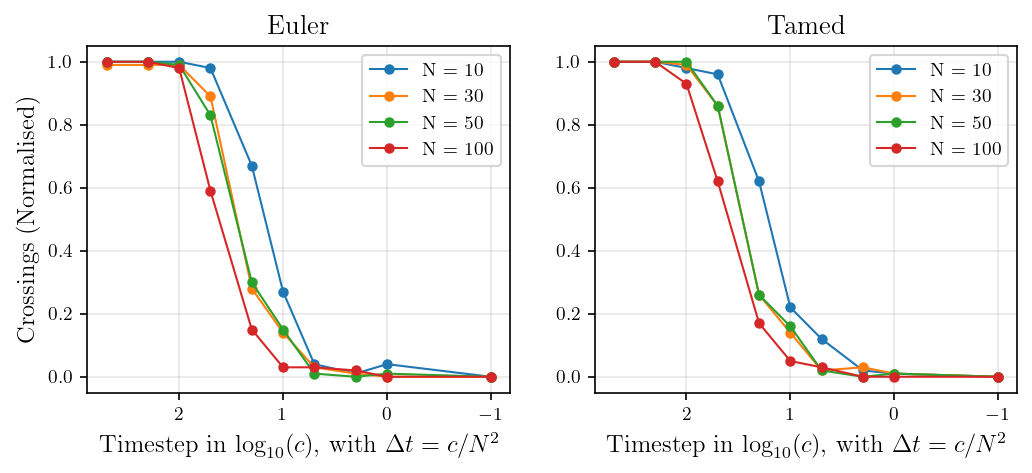

In [ ]:
# CROSSINGS PLOTTER.
crossing_colours = list(plt.cm.tab10.colors) + list(plt.cm.Dark2.colors)
fig, axes = plt.subplots(1, 2)

fixed_Tstar = 1.0

for ax, method in zip(axes, methods):
    if (method == "implicit"):
        continue

    for j, N in enumerate(N_range):
        key = (N, method, fixed_Tstar)
        data = cross_results[key]

        ax.plot(np.log10(data["cs"]), data["crosses"] / data["M"], color = crossing_colours[j], label = f"N = {N}", marker = 'o')
        ax.xaxis.set_inverted(True)
    
    ax.set_title(method.capitalize())
    ax.set_xlabel("Timestep in $\log_{10}(c)$, with $\Delta t = c/N^2$")
    ax.grid(True, alpha = 0.3)
    ax.legend(loc = "upper right")

axes[0].set_ylabel(f"Crossings (Normalised)")

# c_range = [500, 100, 10, 1, 0.1, 0.01] 
plt.show()

Decide how to vary $\Delta t$. Currently have $c/N^2$ for a wide discrete range of $0.1 \leq c \leq 500$. 

---
---
---
---
---

Quick test to see how many iterations the Newton solve uses.

In [ ]:
# Newton iterations experiment.
importlib.reload(sampler);
np.concatenate([np.arange(10, 200 + 10, 10), np.arange(225, 500 + 25, 25)])
T = 1.0; M = 20;

avg_newton_iters = np.zeros_like(N_range, dtype = "float")
for j, N in enumerate(N_range):
    clear_output(wait = True)
    print(f"(O(1/N)): Running for N = {N}.")
    dt = 1/N
    _, newton_iters = sampler.stochastic_sampler(N = N, T = T, dt = dt, method = "implicit", num_trials = M, track_newton = True)
    avg_newton_iters[j] = np.mean(newton_iters.flatten())

#

avg_newton_iters_2 = np.zeros_like(N_range, dtype = "float")
for j, N in enumerate(N_range):
    clear_output(wait = True)
    print(f"(O(1)): Running for N = {N}.")
    dt = 0.1 
    _, newton_iters = sampler.stochastic_sampler(N = N, T = T, dt = dt, method = "implicit", num_trials = M, track_newton = True)
    avg_newton_iters_2[j] = np.mean(newton_iters.flatten())

(O(1)): Running for N = 500.


In [26]:
path = "data/newton_iters_results.pkl"
with open(path, "rb") as f:
    newton_results = pickle.load(f)

newton_results.keys(), newton_results["T"], newton_results["M"], newton_results["O1"]

(dict_keys(['avg_newton_iters', 'avg_newton_iters_2', 'N_range', 'T', 'M', 'O1']),
 1.0,
 20,
 0.1)

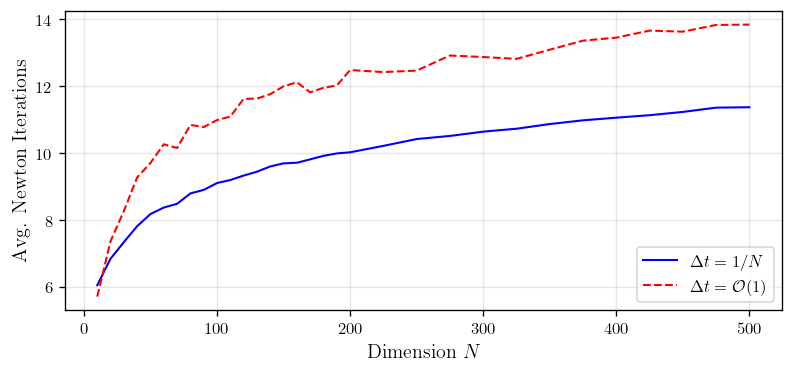

In [ ]:
# PLOTTER for Newton iterations.
nr = newton_results

fig, ax = plt.subplots()
ax.plot(nr["N_range"], nr["avg_newton_iters"], linestyle = "-", color = "blue", label = r"$\Delta t = 1/N$")
ax.plot(nr["N_range"], nr["avg_newton_iters_2"], linestyle = "--", color = "red", label = r"$\Delta t = \mathcal{O}(1)$")
ax.set_xlabel("Dimension $N$")
ax.set_ylabel("Avg. Newton Iterations")
# ax.set_title("Implicit scheme ran until $T = 1$, averaged over $M = 20$ trials.")
ax.legend(loc = "lower right")
ax.grid(True, alpha = 0.3)

# plt.savefig("figures/newton-iters-test.pdf", format = "pdf")
plt.show()

---
---
---
---
---

FMM implementation for the Coulomb interaction.

In [ ]:
# FMM experiment.
importlib.reload(fmm):

def direct_coulomb(lambdas):
    N  = len(lambdas)
    diff = np.subtract.outer(lambdas, lambdas)
    np.fill_diagonal(diff, np.inf)
    return np.sum(1.0 / diff, axis = 1) / N

N_range = [100, 250, 500, 1000, 2000, 5000, 10000, 20000, 30000]
p_range = [3, 5, 10]
trials = 2
results = {}

for N, p in itertools.product(N_range, p_range):
    avg_error = 0; max_error = 0;
    t_fmm = 0; t_direct = 0

    for j in range(trials):
        clear_output(wait = True)
        print(f"Running N = {N}, p = {p}, trial {j + 1} of {trials}.")
        lambdas = np.sort(np.random.randn(N))

        t0 = time.perf_counter()
        f_fmm = fmm.fmm_coulomb_1d(lambdas, p = p)
        t_fmm += time.perf_counter() - t0

        t0 = time.perf_counter()
        f_direct = direct_coulomb(lambdas)
        t_direct += time.perf_counter() - t0

        abs_error = np.abs(f_fmm - f_direct)
        avg_error += abs_error.mean()
        if abs_error.max() > max_error:
            max_error = abs_error.max() 

    # Dictionary very convenient with pickle.
    key = (N, p)
    results[(key)] = {
        "t_fmm" : t_fmm / trials,
        "t_direct" : t_direct / trials,
        "max_err": max_error,
        "mean_err": avg_error / trials,
    }

# 
path = "data/fmm_experiment_results.pkl"
with open(path, "wb") as f:
    pickle.dump(results, f)

Running N = 30000, p = 10, trial 2 of 2.


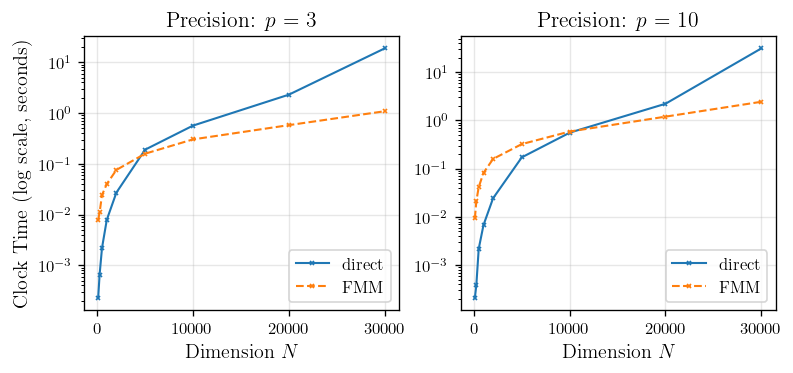

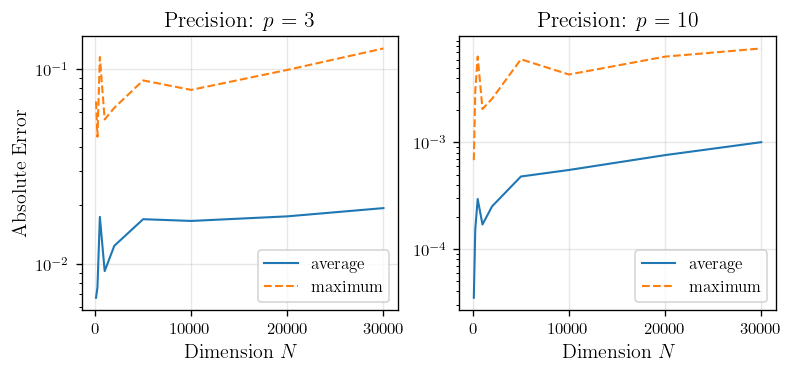

In [ ]:
# FMM plotter 
N_range = [100, 250, 500, 1000, 2000, 5000, 10000, 20000, 30000]
p_range = [3, 5, 10]

path = "data/fmm_experiment_results.pkl"
with open(path, "rb") as f:
    results = pickle.load(f)

fig1, axes = plt.subplots(1, 2)
fig2, axes2 = plt.subplots(1, 2)
ps_plot = [3, 10]

for p, ax, ax2 in zip(ps_plot, axes, axes2):
    t_fmm_values = [results[(N, p)]["t_fmm"] for N in N_range]
    t_direct_values = [results[(N, p)]["t_direct"] for N in N_range]
    ax.plot(N_range, t_direct_values, label = "direct", linestyle = "-", marker = 'x')
    ax.plot(N_range, t_fmm_values, label = "FMM", linestyle = "--", marker = 'x')

    avg_error_values = [results[(N, p)]["mean_err"] for N in N_range]
    max_error_values = [results[(N, p)]["max_err"] for N in N_range]
    ax2.plot(N_range, avg_error_values, label = "average", linestyle = "-")
    ax2.plot(N_range, max_error_values, label = "maximum", linestyle = "--")

    ax.set_title(f"Precision: $p$ = {p}")
    ax2.set_title(f"Precision: $p$ = {p}")
    ax.legend(loc = "lower right")
    ax2.legend(loc = "lower right")

for ax in np.concatenate((axes, axes2)):
    ax.grid(True, alpha = 0.3)
    ax.set_xlabel("Dimension $N$")
    # ax.set_xscale("log")
    ax.set_yscale("log")

axes[0].set_ylabel("Clock Time (log scale, seconds)")
axes2[0].set_ylabel("Absolute Error")

# fig1.savefig("figures/fmm-coulomb-time.pdf", dpi = 100, format = "pdf")
# fig2.savefig("figures/fmm-coulomb-error.pdf", dpi = 100, format = "pdf")

plt.show()